In [56]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict
from IPython.display import Image

In [57]:
# Defining the state
class BMIState(TypedDict):
    height_m: int
    weight_kg: float
    bmi: float
    category: str

In [58]:
def calculate_bmi(state: BMIState) -> BMIState:
    height = state['height_m']
    weight = state['weight_kg']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
    return state

In [63]:
def find_category(state:BMIState)-> BMIState:
    bmi = state['bmi']
    if bmi <18.5:
        state['category'] = "Underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"
    elif 25 <= bmi <30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese"
    return state

In [64]:
graph = StateGraph(BMIState)

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node("find_category",find_category)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge("calculate_bmi","find_category")
graph.add_edge("find_category",END)


In [65]:
compilation= graph.compile()

In [68]:
initial_state = {'height_m':1.5,'weight_kg': 50}
result= compilation.invoke(initial_state)
result

{'height_m': 1.5, 'weight_kg': 50, 'bmi': 22.22, 'category': 'Normal'}

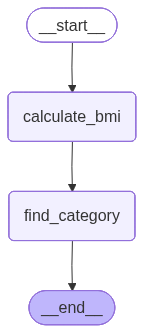

In [69]:
Image(compilation.get_graph().draw_mermaid_png())